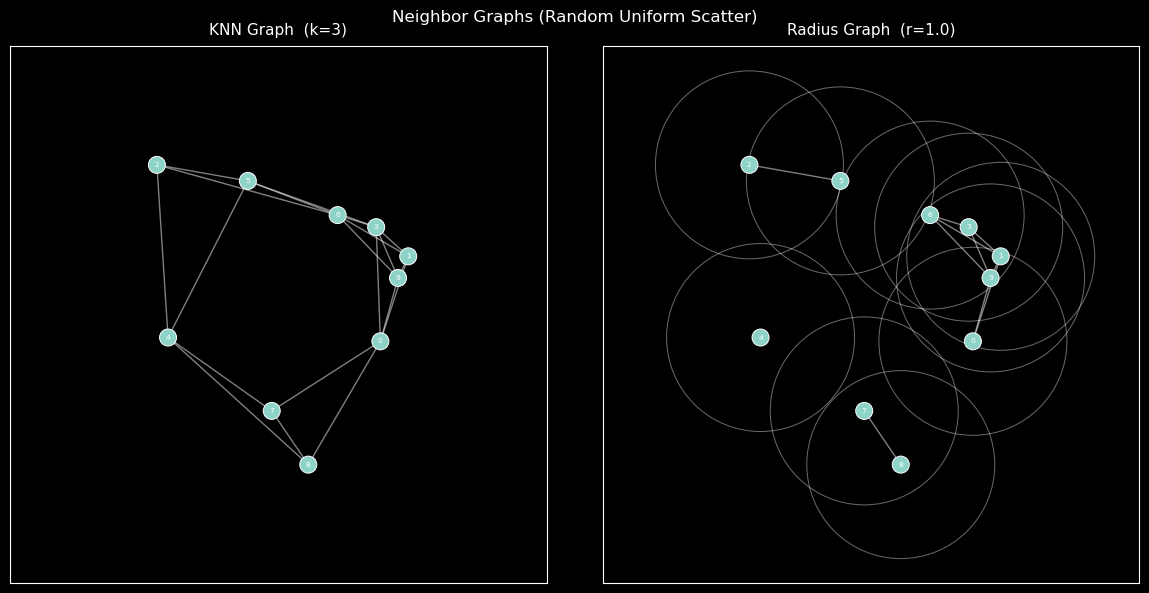

,KNN (k=3),Radius (r=1.0)
nodes,10,10
edges,20,10
min degree,3,0
avg degree,4.0,2.0
max degree,5,4
connected,True,False
components,1,4


In [22]:
"""
Neighbor Graph Demo: K-Nearest Neighbors & Radius Neighbor Graphs
Paste into a Jupyter notebook cell (or run cell-by-cell).

Dataset options:
    "uniform"       – random uniform scatter (no clusters)
    "blobs"         – isotropic Gaussian blobs
    "circles"       – concentric circles
    "moons"         – two interleaving half-moons
    "anisotropic"   – blobs stretched along random directions
    "varied"        – blobs with different per-cluster variance
    "grid"          – regular grid + small jitter
    "spiral"        – two interleaving Archimedean spirals
    "ring"          – points sampled on a noisy ring
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import pandas as pd
from sklearn.neighbors import kneighbors_graph, radius_neighbors_graph
from sklearn.datasets import make_blobs, make_circles, make_moons

# ══════════════════════════════════════════════════════════════════════════════
#  SECTION 1 — Dataset generator functions
# ══════════════════════════════════════════════════════════════════════════════

def make_uniform(n_samples=40, seed=42):
    """Random uniform scatter inside the unit square."""
    rng = np.random.default_rng(seed)
    X = rng.uniform(0, 1, size=(n_samples, 2))
    return X, np.zeros(n_samples, dtype=int)


def make_blobs_dataset(n_samples=40, seed=42):
    """Three isotropic Gaussian blobs."""
    return make_blobs(n_samples=n_samples, centers=3,
                      cluster_std=0.6, random_state=seed)


def make_circles_dataset(n_samples=40, seed=42):
    """Two concentric circles (inner/outer ring)."""
    return make_circles(n_samples=n_samples, noise=0.05,
                        factor=0.4, random_state=seed)


def make_moons_dataset(n_samples=40, seed=42):
    """Two interleaving half-moon shapes."""
    return make_moons(n_samples=n_samples, noise=0.05, random_state=seed)


def make_anisotropic(n_samples=40, seed=42):
    """Blobs stretched by a random linear transformation."""
    X, labels = make_blobs(n_samples=n_samples, centers=3,
                           cluster_std=1.0, random_state=seed)
    rng = np.random.default_rng(seed)
    X = X @ rng.standard_normal((2, 2))
    return X, labels


def make_varied_variance(n_samples=40, seed=42):
    """Blobs where each cluster has a different spread."""
    return make_blobs(n_samples=n_samples,
                      cluster_std=[0.3, 1.0, 1.8],
                      random_state=seed)


def make_grid(n_samples=40, seed=42):
    """Regular grid of points with small Gaussian jitter."""
    side = int(np.ceil(np.sqrt(n_samples)))
    xs, ys = np.meshgrid(np.linspace(0, 1, side), np.linspace(0, 1, side))
    X = np.column_stack([xs.ravel(), ys.ravel()])[:n_samples]
    X += np.random.default_rng(seed).normal(0, 0.02, X.shape)
    return X, np.zeros(len(X), dtype=int)


def make_spiral(n_samples=40, seed=42):
    """Two interleaving Archimedean spirals."""
    rng = np.random.default_rng(seed)
    half = n_samples // 2
    t = np.linspace(0, 4 * np.pi, half)
    noise = rng.normal(0, 0.1, half)
    X0 = np.column_stack([ t * np.cos(t) + noise,  t * np.sin(t) + noise])
    X1 = np.column_stack([-t * np.cos(t) + noise, -t * np.sin(t) + noise])
    return np.vstack([X0, X1]), np.array([0]*half + [1]*half)


def make_ring(n_samples=40, seed=42):
    """Points sampled uniformly on a noisy ring."""
    rng = np.random.default_rng(seed)
    theta = rng.uniform(0, 2 * np.pi, n_samples)
    r = 1.0 + rng.normal(0, 0.08, n_samples)
    X = np.column_stack([r * np.cos(theta), r * np.sin(theta)])
    return X, np.zeros(n_samples, dtype=int)


# ══════════════════════════════════════════════════════════════════════════════
#  SECTION 2 — Graph builder functions
# ══════════════════════════════════════════════════════════════════════════════

def build_knn_graph(X, n_neighbors=3, directed=False):
    """Build a KNN graph from point array X."""
    matrix = kneighbors_graph(X, n_neighbors=n_neighbors,
                              mode="connectivity", include_self=False)
    G = nx.from_scipy_sparse_array(matrix, create_using=nx.DiGraph())
    return G if directed else G.to_undirected()


def build_radius_graph(X, radius=1.0):
    """Build a radius neighbor graph from point array X."""
    matrix = radius_neighbors_graph(X, radius=radius,
                                    mode="connectivity", include_self=False)
    return nx.from_scipy_sparse_array(matrix, create_using=nx.Graph())


# ══════════════════════════════════════════════════════════════════════════════
#  SECTION 3 — Stats as DataFrame
# ══════════════════════════════════════════════════════════════════════════════

def graph_stats_df(knn_G, radius_G, n_neighbors, radius):
    """Return a side-by-side DataFrame comparing both graphs."""
    def stats(G):
        degrees = [d for _, d in G.degree()]
        return {
            "nodes":       G.number_of_nodes(),
            "edges":       G.number_of_edges(),
            "min degree":  min(degrees),
            "avg degree":  round(np.mean(degrees), 2),
            "max degree":  max(degrees),
            "connected":   nx.is_connected(G),
            "components":  nx.number_connected_components(G),
        }

    df = pd.DataFrame({
        f"KNN (k={n_neighbors})":    stats(knn_G),
        f"Radius (r={radius})":      stats(radius_G),
    })
    return df


# ══════════════════════════════════════════════════════════════════════════════
#  SECTION 4 — Visualization
# ══════════════════════════════════════════════════════════════════════════════

def draw_neighbor_graph(ax, G, pos, node_colors, title):
    nx.draw_networkx_edges(ax=ax, G=G, pos=pos,
                           alpha=0.5, edge_color="white", width=1)
    nx.draw_networkx_nodes(ax=ax, G=G, pos=pos,
                           node_color=node_colors, node_size=150,
                           edgecolors="white", linewidths=0.7)
    nx.draw_networkx_labels(ax=ax, G=G, pos=pos,
                            font_size=5.5, font_color="white")
    ax.set_title(title, fontsize=11, pad=8)
    ax.axis("on")  # nx turns axis off internally — re-enable it


def draw_radius_circles(ax, X, radius):
    """Draw a radius circle around every node on the radius graph panel."""
    for point in X:
        circle = mpatches.Circle(
            point, radius,
            fill=False, edgecolor="white",
            linewidth=0.75, alpha=0.4
        )
        ax.add_patch(circle)

    ax.autoscale_view()


def plot_both_graphs(X, labels, knn_G, radius_G, dataset_label, n_neighbors, radius):
    pos = {i: X[i] for i in range(len(X))}
    node_colors = [f"C{l}" for l in labels]

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    fig.suptitle(f"Neighbor Graphs ({dataset_label})")

    draw_neighbor_graph(axes[0], knn_G, pos, node_colors, f"KNN Graph  (k={n_neighbors})")
    draw_neighbor_graph(axes[1], radius_G, pos, node_colors, f"Radius Graph  (r={radius})")
    draw_radius_circles(axes[1], X, radius)

    # ------------------------------------------------------------
    # 1) Gather all limits
    # ------------------------------------------------------------
    x_mins, x_maxs, y_mins, y_maxs = [], [], [], []

    for ax in axes:
        xmin, xmax = ax.get_xlim()
        ymin, ymax = ax.get_ylim()
        x_mins.append(xmin)
        x_maxs.append(xmax)
        y_mins.append(ymin)
        y_maxs.append(ymax)

    # ------------------------------------------------------------
    # 2) Global min/max across EVERYTHING
    # ------------------------------------------------------------
    global_min = min(min(x_mins), min(y_mins))
    global_max = max(max(x_maxs), max(y_maxs))

    # ------------------------------------------------------------
    # 3) Apply same square limits + ticks everywhere.
    #    AutoLocator must run AFTER limits are set — doing it
    #    earlier (inside draw_neighbor_graph) has no effect because
    #    set_aspect/set_xlim invalidate the earlier calculation.
    # ------------------------------------------------------------
    for ax in axes:
        ax.set_xlim(global_min, global_max)
        ax.set_ylim(global_min, global_max)
        ax.set_aspect('equal', adjustable='box')
        ax.xaxis.set_major_locator(plt.AutoLocator())
        ax.yaxis.set_major_locator(plt.AutoLocator())

    plt.tight_layout()
    plt.show()


# ══════════════════════════════════════════════════════════════════════════════
#  SECTION 5 — Run  (change these values and re-run the cell)
# ══════════════════════════════════════════════════════════════════════════════

# Registry: name → (function, human-readable label)
DATASETS = {
    "uniform":     (make_uniform,         "Random Uniform Scatter"),
    "blobs":       (make_blobs_dataset,   "Gaussian Blobs"),
    "circles":     (make_circles_dataset, "Concentric Circles"),
    "moons":       (make_moons_dataset,   "Two Moons"),
    "anisotropic": (make_anisotropic,     "Anisotropic Blobs"),
    "varied":      (make_varied_variance, "Varied Variance Blobs"),
    "grid":        (make_grid,            "Jittered Grid"),
    "spiral":      (make_spiral,          "Double Spiral"),
    "ring":        (make_ring,            "Noisy Ring"),
}

DATASET_NAME = "uniform"   # any key from DATASETS above
N_SAMPLES    = 10
N_NEIGHBORS  = 3           # k for KNN graph
RADIUS       = 1.0         # r for radius graph
SEED         = 42

gen_fn, dataset_label = DATASETS[DATASET_NAME]
X, labels = gen_fn(n_samples=N_SAMPLES, seed=SEED)

X = X - X.mean(axis=0)
X = X / X.std(axis=0).max()

knn_G    = build_knn_graph(X, n_neighbors=N_NEIGHBORS)
radius_G = build_radius_graph(X, radius=RADIUS)

plot_both_graphs(X, labels, knn_G, radius_G, dataset_label, N_NEIGHBORS, RADIUS)

graph_stats_df(knn_G, radius_G, N_NEIGHBORS, RADIUS)